# Figure 5: Sea Ice Regime Analysis and Chlorophyll-*a* Response (1998-2023)

## Purpose
This notebook generates **Figure 5** for the GRL manuscript, analyzing:
- **Panel A**: Classification of sea ice regimes based on standardized anomalies
- **Panel B**: Mean chlorophyll-*a* response by regime across three frontal zones
- Statistical comparison of chlorophyll-*a* concentrations across ice regimes

## Data Sources

### 1. Sea Ice Extent (SIE)
- **Source**: NSIDC Sea Ice Index (1998-2023)
- **Processing**: Annual mean extent calculated
- **Standardization**: Z-scores computed as (x - μ)/σ
- **Units**: Standardized anomalies (dimensionless)

### 2. Chlorophyll-*a* Concentration
- **Source**: Copernicus GlobColour Level 3 (1998-2023)
- **Processing**: Annual means by frontal zone
- **Regions**: PF-SACCF, SACCF-SB, SB-AntCoastline
- **Units**: mg m⁻³

## Methods Overview

### Sea Ice Regime Classification
**Definition of regimes:**
- **High Ice Regime**: Standardized SIE anomaly > +0.5σ
- **Normal Ice Regime**: Standardized SIE anomaly between -0.5σ and +0.5σ
- **Low Ice Regime**: Standardized SIE anomaly < -0.5σ

**Rationale:**
- Based on D'Adamo et al. (2000) approach for Southern Ocean regime analysis
- 0.5σ threshold captures meaningful departures from mean conditions
- Allows examination of ecosystem response to distinct ice states

**Regime distribution (1998-2023):**
- High Ice: 9 years
- Normal Ice: 10 years
- Low Ice: 7 years

### Statistical Analysis
**Kruskal-Wallis H-test:**
- Non-parametric test for differences among three or more groups
- Null hypothesis: Chlorophyll distributions are the same across regimes
- Significance level: α = 0.05
- More robust than ANOVA for non-normal data

**Test results by region:**
- **PF-SACCF**: H = 4.017, p = 0.134 (not significant)
- **SACCF-SB**: H = 5.196, p = 0.074 (not significant)
- **SB-AntCoastline**: H = 3.829, p = 0.147 (not significant)

*Note: Lack of statistical significance likely due to:*
1. Small sample sizes per regime (n=7-10)
2. High natural variability in chlorophyll-*a*
3. Confounding factors (mixing, light, temperature)

### Mean Chlorophyll-*a* by Regime

**Regional patterns:**

| Region | Low Ice | Normal Ice | High Ice |
|--------|---------|------------|----------|
| **PF-SACCF** | 0.197 ± 0.009 | 0.205 ± 0.012 | 0.211 ± 0.013 |
| **SACCF-SB** | 0.225 ± 0.015 | 0.233 ± 0.017 | 0.246 ± 0.021 |
| **SB-AntCoastline** | 0.278 ± 0.025 | 0.294 ± 0.022 | 0.304 ± 0.025 |

*Values shown as mean ± standard deviation (mg m⁻³)*

## Key Results

### Panel A: Sea Ice Regime Time Series
- **Regime transitions** marked with vertical dashed lines
- **Color coding**:
  - Blue background: High Ice regime
  - Gray background: Normal Ice regime
  - Red/orange background: Low Ice regime
- **Notable features**:
  - Predominantly high ice conditions 2008-2015
  - Transition to low ice regime post-2016
  - Rapid shift suggests potential climate tipping point

### Panel B: Chlorophyll-*a* Response by Regime
**Consistent gradient across all zones:**
- **Low Ice → Low Chl-*a***
- **Normal Ice → Intermediate Chl-*a***
- **High Ice → High Chl-*a***

**Regional differences in magnitude:**
- SB-AntCoastline shows largest absolute response (9.4% increase from Low to High Ice)
- SACCF-SB shows intermediate response (9.3% increase)
- PF-SACCF shows smallest response (7.1% increase)

**Error bars:** Standard error of the mean (SEM = σ/√n)

### Ecological Implications

**Higher chlorophyll during high ice years suggests:**
1. **Iron fertilization**: More ice melt releases iron-rich water
2. **Enhanced stratification**: Meltwater stabilizes upper ocean, improving light conditions
3. **Habitat provision**: Ice edge blooms contribute to regional productivity
4. **Longer growing season**: Earlier retreat extends productive period

**Low ice regime consequences:**
- Reduced stratification → deeper mixed layer → light limitation
- Less iron input from reduced meltwater
- Loss of ice-edge bloom habitat
- Potential shift in phytoplankton community composition

## Statistical Notes

### Kruskal-Wallis Interpretation
- **p > 0.05** indicates no statistically significant difference
- Does NOT mean no biological difference exists
- Power limited by:
  - Short time series (26 years)
  - Unequal regime occurrence
  - High natural variability

### Observed Trends vs. Statistical Significance
While not statistically significant, consistent positive gradients across all three independent regions suggest a real biological pattern worthy of further investigation with longer time series.

## Regime Shift Analysis (2015-2016)

The transition from predominantly high/normal ice (1998-2015) to predominantly low ice (2016-2023) represents a potential regime shift:
- **Magnitude**: ~1.5σ change in standardized SIE
- **Persistence**: Low ice conditions maintained for 7+ years
- **Biological response**: Concurrent chlorophyll-*a* declines
- **Implications**: May represent "new normal" with reduced productivity

## Outputs
- **Figure_5.png**: Two-panel figure (300 DPI)
  - Panel A: Sea ice regime classification time series
  - Panel B: Chlorophyll-*a* response by regime (bar chart with error bars)
- Format suitable for GRL publication

---

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif',  # Using serif font for consistency
    # 'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    # 'mathtext.fontset': 'dejavusans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'axes.linewidth': 1.0,
    'savefig.dpi': 600,
})
# Set matplotlib and seaborn style and parameters for journal-quality figures
sns.set_theme(style="whitegrid", context="paper")
print("Libraries imported successfully")

Libraries imported successfully


## 1. Data Loading and Preparation

In [2]:
# Load sea ice data
def load_sea_ice_data(file_path):
    """
    Load sea ice extent data from CSV file
    
    Parameters:
    file_path (str): Path to the SIEA CSV file
    
    Returns:
    pd.DataFrame: Sea ice data with datetime index
    """
    try:
        sie = pd.read_csv(file_path)
        sie.set_index('time', inplace=True)
        sie.index = pd.to_datetime(sie.index)
        
        print("✅ Sea ice data loaded successfully")
        print(f"   Data shape: {sie.shape}")
        print(f"   Available columns: {sie.columns.tolist()}")
        print(f"   Time range: {sie.index.min().strftime('%Y-%m')} to {sie.index.max().strftime('%Y-%m')}")
        
        if 'extent' in sie.columns:
            print(f"   Sea ice extent range: {sie['extent'].min():.2f} - {sie['extent'].max():.2f} million km²")
        
        return sie
        
    except FileNotFoundError:
        print("❌ Sea ice data file not found")
        print(f"   Please check the file path: {file_path}")
        return None
    except Exception as e:
        print(f"❌ Error loading sea ice data: {e}")
        return None

# Load chlorophyll-a data
def load_chlorophyll_data(file_path):
    """
    Load chlorophyll-a concentration data from CSV file
    
    Parameters:
    file_path (str): Path to the chlorophyll CSV file
    
    Returns:
    pd.DataFrame: Chlorophyll data with datetime index
    """
    try:
        chl = pd.read_csv(file_path)
        chl['time'] = pd.to_datetime(chl['time'])
        chl.set_index('time', inplace=True)
        
        print("✅ Chlorophyll-a data loaded successfully")
        print(f"   Data shape: {chl.shape}")
        print(f"   Available regions: {chl.columns.tolist()}")
        print(f"   Time range: {chl.index.min().strftime('%Y-%m')} to {chl.index.max().strftime('%Y-%m')}")
        
        return chl
        
    except FileNotFoundError:
        print("❌ Chlorophyll-a data file not found")
        print(f"   Please check the file path: {file_path}")
        return None
    except Exception as e:
        print(f"❌ Error loading chlorophyll data: {e}")
        return None

# Load the data
sie_data_path = "/A04/so_data/ubuntu/Chapter_2/SIEA_1998_2023.csv"
chl_data_path = "/A04/so_data/Revised_data/file_L3_2023_nb.csv"

sie = load_sea_ice_data(sie_data_path)
chl = load_chlorophyll_data(chl_data_path)

✅ Sea ice data loaded successfully
   Data shape: (312, 3)
   Available columns: ['extent', 'area', 'SIEA']
   Time range: 1998-01 to 2023-12
   Sea ice extent range: 1.91 - 19.76 million km²
✅ Chlorophyll-a data loaded successfully
   Data shape: (312, 8)
   Available regions: ['40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'Southern Ocean', 'PF_AntCoastline']
   Time range: 1998-01 to 2023-12


In [3]:
# Calculate annual averages
def calculate_annual_averages(data, data_name):
    """
    Calculate annual averages from monthly data
    
    Parameters:
    data (pd.DataFrame): Input data with datetime index
    data_name (str): Name for printing
    
    Returns:
    pd.DataFrame: Annual averaged data
    """
    if data is None:
        return None
        
    annual_data = data.resample('YE').mean()
    
    print(f"📊 {data_name} annual averages calculated")
    print(f"   Years: {annual_data.index.year.min()} - {annual_data.index.year.max()}")
    print(f"   Shape: {annual_data.shape}")
    
    return annual_data

# Calculate annual averages for both datasets
sie_annual = calculate_annual_averages(sie, "Sea ice")
chl_annual = calculate_annual_averages(chl, "Chlorophyll-a")

# Display sample data
if sie_annual is not None:
    print("\n📋 Sea ice annual data (first 5 years):")
    print(sie_annual.head())
    
if chl_annual is not None:
    print("\n📋 Chlorophyll-a annual data (first 5 years):")
    print(chl_annual.head())

📊 Sea ice annual averages calculated
   Years: 1998 - 2023
   Shape: (26, 3)
📊 Chlorophyll-a annual averages calculated
   Years: 1998 - 2023
   Shape: (26, 8)

📋 Sea ice annual data (first 5 years):
               extent      area      SIEA
time                                     
1998-12-31  11.689167  8.814167  0.123696
1999-12-31  11.712500  8.829167  0.147030
2000-12-31  11.724167  8.995000  0.158696
2001-12-31  11.627500  8.724167  0.062030
2002-12-31  11.175833  8.505000 -0.389637

📋 Chlorophyll-a annual data (first 5 years):
              40S-NB    NB_SAF    SAF_PF  PF_SACCF  SACCF_SB  SB_AntCoastline  \
time                                                                            
1998-12-31  0.194513  0.191040  0.171704  0.190773  0.206059         0.276036   
1999-12-31  0.196223  0.201737  0.180434  0.196529  0.215683         0.276024   
2000-12-31  0.190666  0.191125  0.174018  0.196950  0.230030         0.297693   
2001-12-31  0.198790  0.197341  0.175326  0.200967  0.2

In [4]:
# Calculate chlorophyll-a percent changes
def calculate_chlorophyll_percent_changes(chl_annual):
    """
    Calculate percent changes in chlorophyll-a for each region
    using climatological mean as baseline
    
    Parameters:
    chl_annual (pd.DataFrame): Annual chlorophyll data
    
    Returns:
    dict: Percent changes for each region
    list: Region names
    list: Region display labels
    """
    if chl_annual is None:
        print("❌ Chlorophyll-a data not available")
        return {}, [], []
    
    # Define regions of interest
    regions = ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']
    region_labels = ['PF-SACCF', 'SACCF-SB', 'SB-Antarctic Coastline']
    
    # Filter regions that exist in the data
    available_regions = [r for r in regions if r in chl_annual.columns]
    
    if not available_regions:
        print("❌ No matching regions found in chlorophyll data")
        return {}, regions, region_labels
    
    chl_percent_changes = {}
    
    for region in regions:
        if region in chl_annual.columns:
            data = chl_annual[region]
            
            # Calculate using climatological mean as baseline
            baseline = data.mean()
            percent_change = ((data - baseline) / baseline) * 100
            
            chl_percent_changes[region] = percent_change
            
            print(f"   {region}: {percent_change.min():.1f}% to {percent_change.max():.1f}%")
    
    print(f"🔢 Chlorophyll-a percent changes calculated for {len(chl_percent_changes)} regions")
    
    return chl_percent_changes, regions, region_labels

# Calculate chlorophyll percent changes using climatological mean baseline
chl_percent_changes, regions, region_labels = calculate_chlorophyll_percent_changes(chl_annual)

   PF_SACCF: -9.5% to 17.2%
   SACCF_SB: -12.5% to 24.4%
   SB_AntCoastline: -19.6% to 21.2%
🔢 Chlorophyll-a percent changes calculated for 3 regions


## 3. Statistical Analysis

In [5]:
# D'Adamo regime pattern analysis
def analyze_sea_ice_regimes(sie_annual, window_size=5):
    """
    Analyze sea ice regime patterns similar to D'Adamo studies
    
    Parameters:
    sie_annual (pd.DataFrame): Annual sea ice extent data
    window_size (int): Window size for regime detection
    
    Returns:
    dict: Regime analysis results
    """
    if sie_annual is None or 'extent' not in sie_annual.columns:
        print("❌ Sea ice extent data not available")
        return None
    
    extent_data = sie_annual['extent']
    
    # Calculate regime indicators
    regime_analysis = {}
    
    # 1. Multi-year means for regime detection
    regime_analysis['rolling_mean'] = extent_data.rolling(window=window_size, center=True).mean()
    
    # 2. Calculate anomalies from climatology
    climatology = extent_data.mean()
    regime_analysis['anomaly'] = extent_data - climatology
    regime_analysis['std_anomaly'] = (extent_data - climatology) / extent_data.std()
    
    # 3. Identify regimes based on standardized anomalies
    threshold = 0.5  # in standard deviations
    conditions = [
        regime_analysis['std_anomaly'] < -threshold,
        (regime_analysis['std_anomaly'] >= -threshold) & (regime_analysis['std_anomaly'] <= threshold),
        regime_analysis['std_anomaly'] > threshold
    ]
    choices = ['Low Ice', 'Normal Ice', 'High Ice']
    
    regime_analysis['regime'] = pd.Series(
        np.select(conditions, choices, default='Normal Ice'),
        index=extent_data.index
    )
    
    # 4. Count years in each regime
    regime_counts = regime_analysis['regime'].value_counts()
    print("📊 Sea Ice Regime Analysis:")
    for regime, count in regime_counts.items():
        print(f"   {regime}: {count} years")
    
    return regime_analysis

# Function to calculate mean chlorophyll-a ± std for each regime across the three regions
def calculate_regime_chlorophyll_stats(regime_analysis, chl_annual, regions):
    """
    Calculate mean chlorophyll-a ± standard deviation for each sea ice regime by region
    
    Parameters:
    regime_analysis (dict): Sea ice regime analysis results
    chl_annual (DataFrame): Annual chlorophyll-a data
    regions (list): List of region names ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']
    
    Returns:
    dict: Chlorophyll-a statistics by regime and region
    """
    if regime_analysis is None or 'regime' not in regime_analysis:
        print("❌ Regime analysis data not available")
        return None
        
    if chl_annual is None:
        print("❌ Chlorophyll-a data not available")
        return None
    
    regimes = ['Low Ice', 'Normal Ice', 'High Ice']
    regime_chl_stats = {}
    
    print("\n📊 Mean Chlorophyll-a (± Std Dev) by Sea Ice Regime for Each Region:")
    print("="*80)
    
    # Process each region separately
    for region in ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']:
        if region not in chl_annual.columns:
            print(f"❌ Region '{region}' not found in chlorophyll data")
            continue
            
        print(f"\n🌊 REGION: {region}")
        print("-" * 50)
        
        regime_chl_stats[region] = {}
        
        for regime in regimes:
            # Get years with this regime
            regime_years = regime_analysis['regime'][regime_analysis['regime'] == regime].index
            
            # Get chlorophyll values for this regime in this specific region
            region_chl = chl_annual.loc[chl_annual.index.year.isin(regime_years.year), region]
            
            if not region_chl.empty and not region_chl.isna().all():
                # Remove NaN values
                valid_chl_data = region_chl.dropna()
                
                if len(valid_chl_data) > 0:
                    # Calculate statistics for this region and regime
                    mean_chl = valid_chl_data.mean()
                    std_chl = valid_chl_data.std(ddof=1) if len(valid_chl_data) > 1 else 0
                    n_points = len(valid_chl_data)
                    sem_chl = std_chl / np.sqrt(n_points) if n_points > 0 else np.nan
                    min_chl = valid_chl_data.min()
                    max_chl = valid_chl_data.max()
                    
                    regime_chl_stats[region][regime] = {
                        'mean': mean_chl,
                        'std': std_chl,
                        'sem': sem_chl,
                        'min': min_chl,
                        'max': max_chl,
                        'n': n_points,
                        'years': regime_years.year.tolist()
                    }
                    
                    print(f"  {regime}:")
                    print(f"    Mean: {mean_chl:.3f} ± {std_chl:.3f} mg/m³")
                    print(f"    Range: {min_chl:.3f} - {max_chl:.3f} mg/m³")
                    print(f"    SEM: {sem_chl:.3f} mg/m³")
                    print(f"    n = {n_points} years")
                else:
                    print(f"  {regime}: No valid data")
            else:
                print(f"  {regime}: No data available")
    
    # Create comprehensive summary table
    print(f"\n📋 SUMMARY TABLE: Chlorophyll-a Statistics by Region and Sea Ice Regime")
    print("="*90)
    print(f"{'Region':<15} {'Regime':<12} {'Mean':<8} {'±Std':<8} {'SEM':<8} {'Min':<8} {'Max':<8} {'n':<4}")
    print("-"*90)
    
    for region in ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']:
        if region in regime_chl_stats:
            for regime in regimes:
                if regime in regime_chl_stats[region]:
                    stats = regime_chl_stats[region][regime]
                    print(f"{region:<15} {regime:<12} {stats['mean']:<8.3f} {stats['std']:<8.3f} "
                          f"{stats['sem']:<8.3f} {stats['min']:<8.3f} {stats['max']:<8.3f} {stats['n']:<4}")
                else:
                    print(f"{region:<15} {regime:<12} {'No data':<8} {'No data':<8} {'No data':<8} {'No data':<8} {'No data':<8} {'N/A':<4}")
    
    # Calculate and display overall means across all three regions for comparison
    print(f"\n📊 OVERALL MEANS (Combined across all three regions):")
    print("-"*60)
    
    overall_stats = {}
    for regime in regimes:
        all_regime_data = []
        
        for region in ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']:
            if region in regime_chl_stats and regime in regime_chl_stats[region]:
                # Get years with this regime
                regime_years = regime_analysis['regime'][regime_analysis['regime'] == regime].index
                region_chl = chl_annual.loc[chl_annual.index.year.isin(regime_years.year), region]
                valid_data = region_chl.dropna()
                if len(valid_data) > 0:
                    all_regime_data.extend(valid_data.values)
        
        if all_regime_data:
            overall_mean = np.mean(all_regime_data)
            overall_std = np.std(all_regime_data, ddof=1)
            overall_n = len(all_regime_data)
            overall_sem = overall_std / np.sqrt(overall_n) if overall_n > 0 else np.nan
            
            overall_stats[regime] = {
                'mean': overall_mean,
                'std': overall_std,
                'sem': overall_sem,
                'n': overall_n
            }
            
            print(f"{regime}: {overall_mean:.3f} ± {overall_std:.3f} mg/m³ (n={overall_n})")
        else:
            print(f"{regime}: No data available")
    
    return regime_chl_stats

# Analyze sea ice regimes
regime_analysis = analyze_sea_ice_regimes(sie_annual)

# Calculate chlorophyll-a statistics by regime if data is available
if regime_analysis is not None and 'chl_annual' in globals() and 'regions' in globals():
    regime_chl_stats = calculate_regime_chlorophyll_stats(regime_analysis, chl_annual, regions)
else:
    print("\n⚠️  Chlorophyll-a regime statistics calculation skipped - data not available")

📊 Sea Ice Regime Analysis:
   Normal Ice: 10 years
   High Ice: 9 years
   Low Ice: 7 years

📊 Mean Chlorophyll-a (± Std Dev) by Sea Ice Regime for Each Region:

🌊 REGION: PF_SACCF
--------------------------------------------------
  Low Ice:
    Mean: 0.197 ± 0.009 mg/m³
    Range: 0.186 - 0.209 mg/m³
    SEM: 0.004 mg/m³
    n = 7 years
  Normal Ice:
    Mean: 0.205 ± 0.012 mg/m³
    Range: 0.191 - 0.234 mg/m³
    SEM: 0.004 mg/m³
    n = 10 years
  High Ice:
    Mean: 0.211 ± 0.013 mg/m³
    Range: 0.200 - 0.240 mg/m³
    SEM: 0.004 mg/m³
    n = 9 years

🌊 REGION: SACCF_SB
--------------------------------------------------
  Low Ice:
    Mean: 0.225 ± 0.015 mg/m³
    Range: 0.209 - 0.253 mg/m³
    SEM: 0.006 mg/m³
    n = 7 years
  Normal Ice:
    Mean: 0.233 ± 0.017 mg/m³
    Range: 0.206 - 0.268 mg/m³
    SEM: 0.005 mg/m³
    n = 10 years
  High Ice:
    Mean: 0.246 ± 0.021 mg/m³
    Range: 0.222 - 0.293 mg/m³
    SEM: 0.007 mg/m³
    n = 9 years

🌊 REGION: SB_AntCoastline
------

In [6]:
import pandas as pd
import numpy as np
from scipy import stats

def perform_regime_kruskal_analysis(regime_analysis, chl_annual, regions):

    if regime_analysis is None or 'regime' not in regime_analysis:
        print("❌ Regime analysis data not available")
        return None

    if chl_annual is None:
        print("❌ Chlorophyll-a data not available")
        return None

    regimes = ['Low Ice', 'Normal Ice', 'High Ice']
    kw_results = {}

    print("\n📊 KRUSKAL–WALLIS TEST: Chlorophyll-a Differences by Sea Ice Regime")
    print("="*85)
    print("Null Hypothesis (H₀): The distribution of chlorophyll-a is the same across regimes")
    print("Alternative Hypothesis (H₁): At least one regime differs")
    print("Significance level: α = 0.05")
    print("="*85)

    summary_data = []

    for region in regions:

        if region not in chl_annual.columns:
            print(f"\n❌ Region '{region}' not found")
            continue

        print(f"\n🌊 REGION: {region}")
        print("-"*50)

        regime_groups = []
        valid_regimes = []

        for regime in regimes:

            regime_years = regime_analysis['regime'][regime_analysis['regime']==regime].index

            region_chl = chl_annual.loc[
                chl_annual.index.year.isin(regime_years.year),
                region
            ]

            valid_chl = region_chl.dropna()

            if len(valid_chl) > 0:
                regime_groups.append(valid_chl.values)
                valid_regimes.append(regime)

                print(f"  {regime}: {len(valid_chl)} values")

        if len(regime_groups) < 2:
            print("  ❌ Not enough groups for test")
            continue

        # Kruskal–Wallis test
        H, p_value = stats.kruskal(*regime_groups)

        is_significant = p_value < 0.05

        if p_value < 0.001:
            sig = "***"
        elif p_value < 0.01:
            sig = "**"
        elif p_value < 0.05:
            sig = "*"
        else:
            sig = "ns"

        print("\n  📈 Kruskal–Wallis Results:")
        print(f"     H-statistic: {H:.3f}")
        print(f"     p-value: {p_value:.5f} {sig}")

        if is_significant:
            print("  ✅ Significant difference between regimes")
        else:
            print("  ❌ No significant difference detected")

        kw_results[region] = {
            "H_statistic": H,
            "p_value": p_value,
            "significance": sig,
            "significant": is_significant
        }

        summary_data.append({
            "Region": region,
            "H-statistic": f"{H:.3f}",
            "p-value": f"{p_value:.5f}",
            "Significant": f"{'Yes' if is_significant else 'No'} {sig}"
        })

    if summary_data:

        print("\n📋 SUMMARY TABLE")
        print("="*70)

        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))

        print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

    return kw_results


# Run analysis
if ('regime_analysis' in globals() and 'chl_annual' in globals() and
    regime_analysis is not None and chl_annual is not None):

    regions = ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']

    regime_kw_results = perform_regime_kruskal_analysis(
        regime_analysis,
        chl_annual,
        regions
    )

else:
    print("❌ Required data not available")


📊 KRUSKAL–WALLIS TEST: Chlorophyll-a Differences by Sea Ice Regime
Null Hypothesis (H₀): The distribution of chlorophyll-a is the same across regimes
Alternative Hypothesis (H₁): At least one regime differs
Significance level: α = 0.05

🌊 REGION: PF_SACCF
--------------------------------------------------
  Low Ice: 7 values
  Normal Ice: 10 values
  High Ice: 9 values

  📈 Kruskal–Wallis Results:
     H-statistic: 4.017
     p-value: 0.13422 ns
  ❌ No significant difference detected

🌊 REGION: SACCF_SB
--------------------------------------------------
  Low Ice: 7 values
  Normal Ice: 10 values
  High Ice: 9 values

  📈 Kruskal–Wallis Results:
     H-statistic: 5.196
     p-value: 0.07441 ns
  ❌ No significant difference detected

🌊 REGION: SB_AntCoastline
--------------------------------------------------
  Low Ice: 7 values
  Normal Ice: 10 values
  High Ice: 9 values

  📈 Kruskal–Wallis Results:
     H-statistic: 3.829
     p-value: 0.14743 ns
  ❌ No significant difference detect

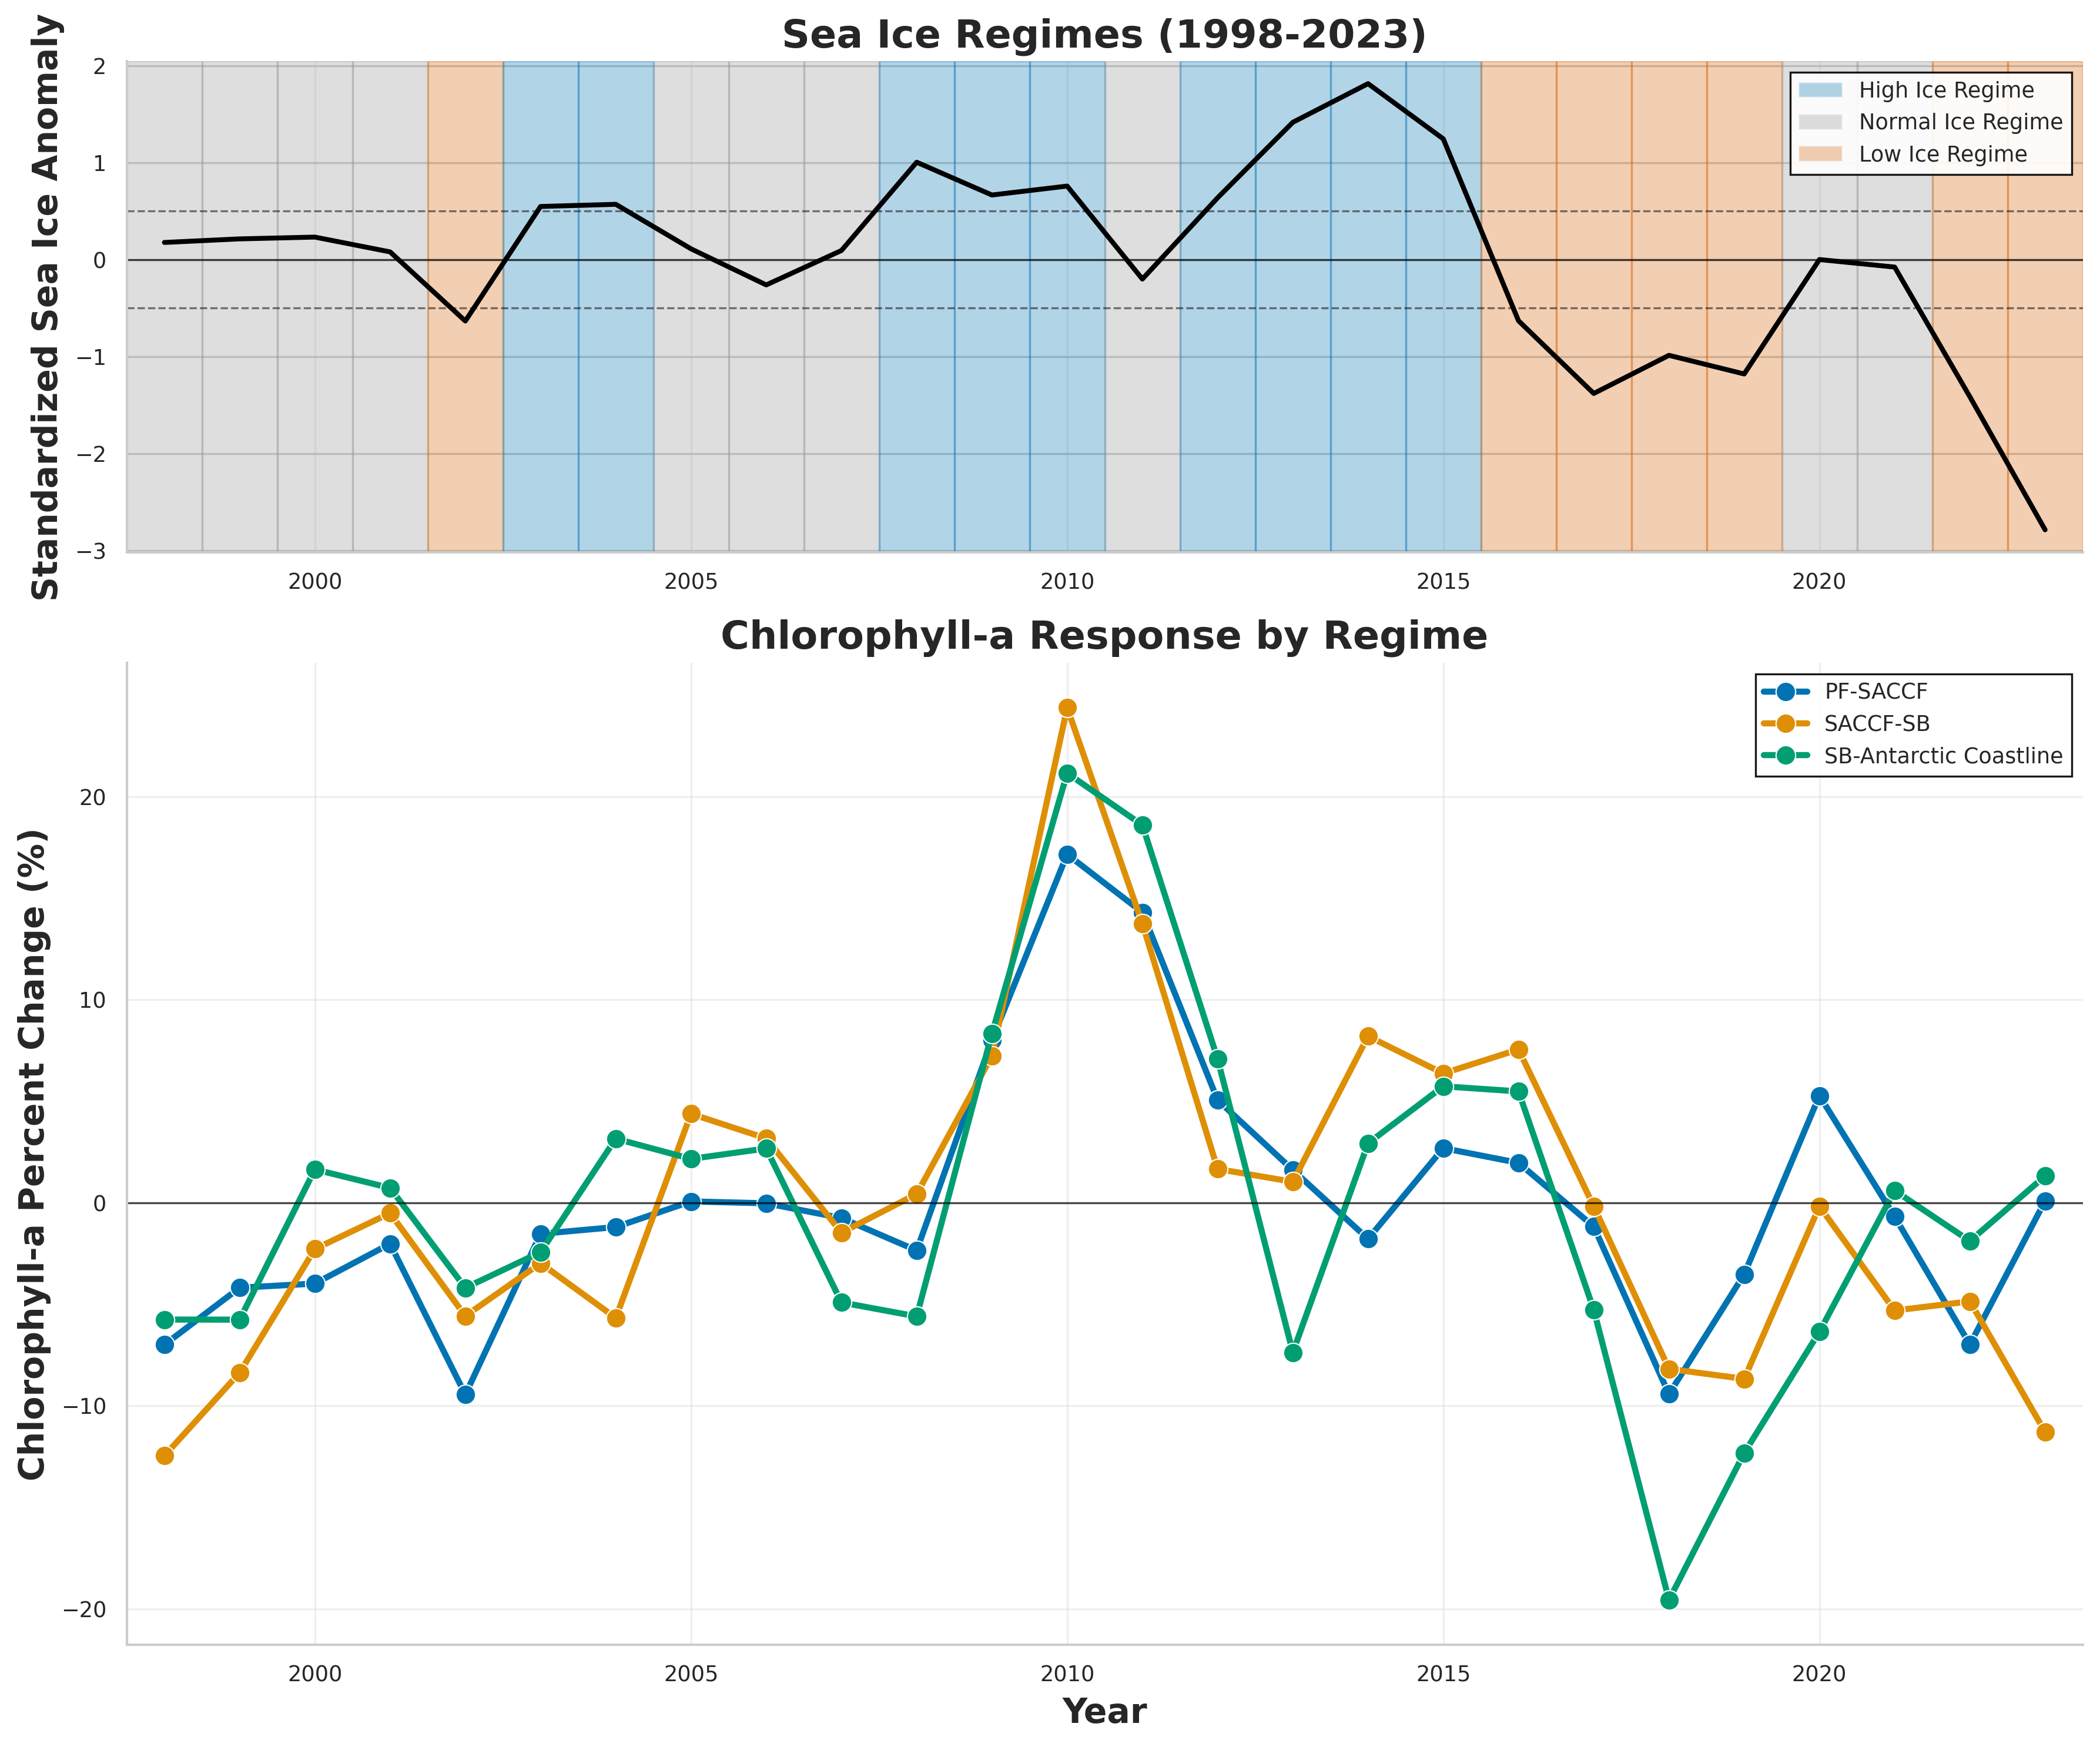

In [7]:
# Create a figure showing sea ice regimes and chlorophyll response with Seaborn styling
def create_regime_figure(regime_analysis, chl_percent_changes, regions):
    """
    Create a journal-quality figure showing sea ice regimes and corresponding chlorophyll responses
    using Seaborn for enhanced visualization
    
    Parameters:
    regime_analysis (dict): Sea ice regime analysis results
    chl_percent_changes (dict): Chlorophyll percent changes by region
    regions (list): List of region names
    
    Returns:
    matplotlib.figure.Figure: The created figure
    """
    if regime_analysis is None or 'regime' not in regime_analysis:
        print("❌ Regime analysis data not available")
        return None
    
    # Use Seaborn styling for publication-quality figures
    with sns.axes_style("whitegrid"):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=300, 
                                      gridspec_kw={'height_ratios': [1, 2]})
    
    # Define a colorblind-friendly palette for regime colors
    palette = sns.color_palette("colorblind")
    regime_colors = {
        'Low Ice': palette[3],    # Red-like
        'Normal Ice': palette[7], # Gray
        'High Ice': palette[0]    # Blue
    }
    
    # Plot sea ice anomalies and regimes on top panel
    years = regime_analysis['std_anomaly'].index.year
    
    # Create colormap for regime background
    for year in years:
        regime = regime_analysis['regime'][f"{year}-12-31"]
        ax1.axvspan(year-0.5, year+0.5, alpha=0.3, color=regime_colors[regime])
    
    # Plot sea ice anomalies with enhanced styling
    ax1.plot(years, regime_analysis['std_anomaly'], color='black', linewidth=2, label="Sea Ice Anomaly")
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
    
    # Add regime threshold lines with subtle styling
    ax1.axhline(y=0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax1.axhline(y=-0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Format top panel for publication
    ax1.set_xlim(years.min()-0.5, years.max()+0.5)
    ax1.set_ylabel('Standardized Sea Ice Anomaly', fontsize=14, fontweight='bold')
    ax1.set_title('Sea Ice Regimes (1998-2023)', fontsize=16, fontweight='bold')
    
    # Add regime labels to the legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=regime_colors['High Ice'], alpha=0.3, label='High Ice Regime'),
        Patch(facecolor=regime_colors['Normal Ice'], alpha=0.3, label='Normal Ice Regime'),
        Patch(facecolor=regime_colors['Low Ice'], alpha=0.3, label='Low Ice Regime')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=False, 
               framealpha=0.9, edgecolor='black')
    
    # Plot chlorophyll changes on bottom panel with enhanced styling
    region_palette = sns.color_palette("colorblind", n_colors=len(regions))
    colors = {regions[i]: region_palette[i] for i in range(len(regions))}
    labels = {'PF_SACCF': 'PF-SACCF', 'SACCF_SB': 'SACCF-SB', 'SB_AntCoastline': 'SB-Antarctic Coastline'}
    
    for i, region in enumerate(regions):
        if region in chl_percent_changes:
            # Plot chlorophyll changes with enhanced markers and styling
            years = chl_percent_changes[region].index.year
            ax2.plot(years, chl_percent_changes[region], 
                    color=colors[region], marker='o', linewidth=2.5, 
                    markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                    label=labels[region])
    
    # Format bottom panel for publication
    ax2.set_xlim(years.min()-0.5, years.max()+0.5)
    ax2.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Chlorophyll-a Percent Change (%)', fontsize=14, fontweight='bold')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
    
    # Create custom legend with enhanced styling
    handles, labels_text = ax2.get_legend_handles_labels()
    ax2.legend(handles, labels_text, loc='best', frameon=True, fancybox=False, 
               framealpha=0.9, edgecolor='black')
    
    ax2.set_title('Chlorophyll-a Response by Regime', fontsize=16, fontweight='bold')
    
    # Add vertical grid lines for easier year comparison
    ax1.grid(True, axis='x', alpha=0.3)
    ax2.grid(True, alpha=0.3)
    
    # Remove unnecessary spines for cleaner look
    sns.despine(fig, ax1)
    sns.despine(fig, ax2)
    
    # Ensure tight layout for publication
    plt.tight_layout()
    return fig

# Create regime figure with Seaborn styling
regime_figure = create_regime_figure(regime_analysis, chl_percent_changes, regions)
plt.show()

In [8]:
# Analyze chlorophyll response by sea ice regime
def analyze_chl_by_regime(regime_analysis, chl_percent_changes):
    """
    Analyze chlorophyll response by sea ice regime
    
    Parameters:
    regime_analysis (dict): Sea ice regime analysis results
    chl_percent_changes (dict): Chlorophyll percent changes by region
    
    Returns:
    dict: Chlorophyll response by regime
    """
    if regime_analysis is None or 'regime' not in regime_analysis:
        print("❌ Regime analysis data not available")
        return None
    
    regimes = ['Low Ice', 'Normal Ice', 'High Ice']
    results = {}
    
    for region, chl_changes in chl_percent_changes.items():
        results[region] = {}
        
        # Group chlorophyll changes by regime
        for regime in regimes:
            # Find years with this regime
            regime_years = regime_analysis['regime'][regime_analysis['regime'] == regime].index
            
            # Get chlorophyll changes for these years
            regime_chl = chl_changes[chl_changes.index.isin(regime_years)]
            
            if not regime_chl.empty:
                results[region][regime] = {
                    'mean': regime_chl.mean(),
                    'std': regime_chl.std(),
                    'min': regime_chl.min(),
                    'max': regime_chl.max(),
                    'count': len(regime_chl)
                }
    
    # Print summary
    print("📊 Chlorophyll Response by Sea Ice Regime")
    print("="*50)
    
    for region, regime_data in results.items():
        print(f"\n🔍 {region}:")
        for regime, stats in regime_data.items():
            print(f"   {regime}: {stats['mean']:.1f}% ± {stats['std']:.1f}% (n={stats['count']})")
    
    return results

# Analyze chlorophyll by regime
chl_by_regime = analyze_chl_by_regime(regime_analysis, chl_percent_changes)

📊 Chlorophyll Response by Sea Ice Regime

🔍 PF_SACCF:
   Low Ice: -4.1% ± 4.6% (n=7)
   Normal Ice: 0.1% ± 6.0% (n=10)
   High Ice: 3.1% ± 6.3% (n=9)

🔍 SACCF_SB:
   Low Ice: -4.5% ± 6.4% (n=7)
   Normal Ice: -0.9% ± 7.2% (n=10)
   High Ice: 4.5% ± 8.8% (n=9)

🔍 SB_AntCoastline:
   Low Ice: -5.2% ± 8.4% (n=7)
   Normal Ice: 0.4% ± 7.4% (n=10)
   High Ice: 3.7% ± 8.6% (n=9)


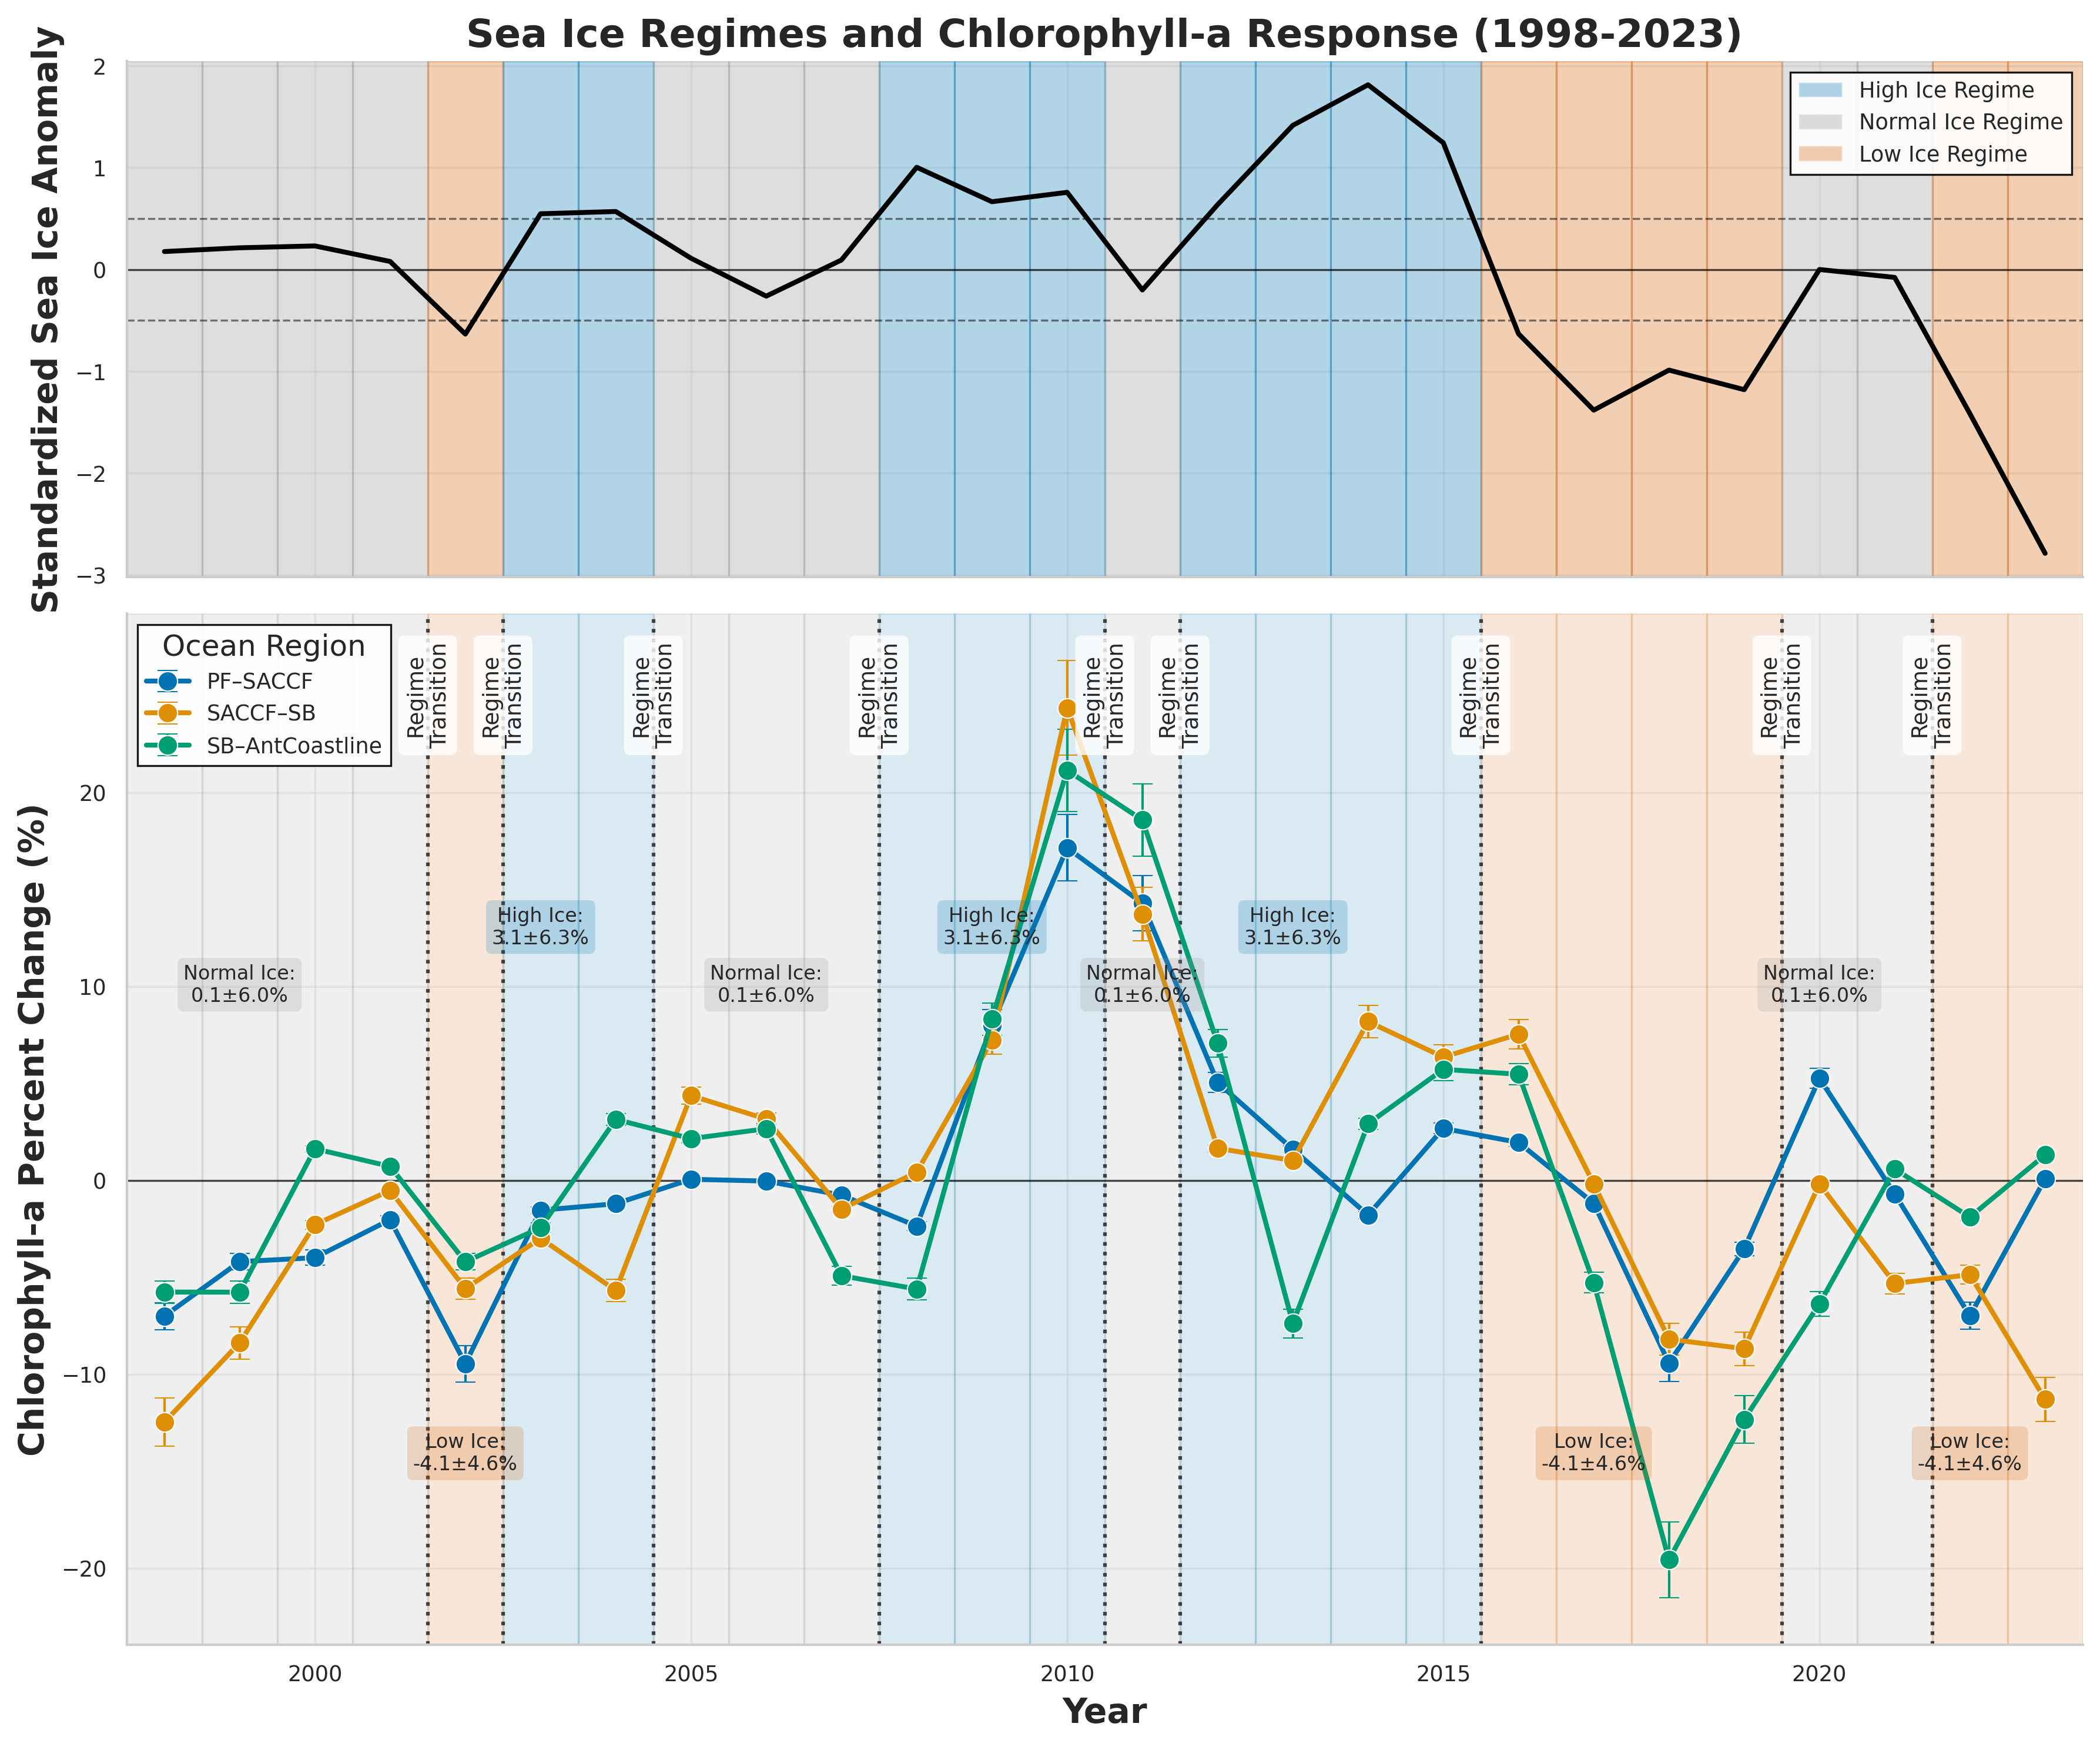

In [9]:
# Create a combined figure with sea ice regimes and chlorophyll response with standard deviation
def create_combined_regime_response_figure(regime_analysis, chl_by_regime, regions):
    """
    Create a journal-quality figure combining sea ice regimes and chlorophyll response with standard deviation
    
    Parameters:
    regime_analysis (dict): Sea ice regime analysis results
    chl_by_regime (dict): Chlorophyll response by regime
    regions (list): List of region names
    
    Returns:
    matplotlib.figure.Figure: The created figure
    """
    if regime_analysis is None or 'regime' not in regime_analysis:
        print("❌ Regime analysis data not available")
        return None
    
    if chl_by_regime is None:
        print("❌ Chlorophyll by regime data not available")
        return None
    
    # Use Seaborn styling for publication-quality figures
    with sns.axes_style("whitegrid"):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=300, 
                                      gridspec_kw={'height_ratios': [1, 2]},
                                      sharex=True)  # Share x-axis for better alignment
    
    # Define colorblind-friendly palettes
    palette = sns.color_palette("colorblind")
    regime_colors = {
        'Low Ice': palette[3],    # Red-like
        'Normal Ice': palette[7], # Gray
        'High Ice': palette[0]    # Blue
    }
    
    # Plot sea ice anomalies and regimes on top panel
    years = regime_analysis['std_anomaly'].index.year
    years_range = np.arange(min(years), max(years) + 1)
    
    # Create colormap for regime background that spans both subplots
    for year in years:
        regime = regime_analysis['regime'][f"{year}-12-31"]
        ax1.axvspan(year-0.5, year+0.5, alpha=0.3, color=regime_colors[regime])
        # Add same background to bottom panel for visual continuity
        ax2.axvspan(year-0.5, year+0.5, alpha=0.15, color=regime_colors[regime])
    
    # Plot sea ice anomalies with enhanced styling
    ax1.plot(years, regime_analysis['std_anomaly'], color='black', linewidth=2, label="Sea Ice Anomaly")
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
    
    # Add regime threshold lines with subtle styling
    ax1.axhline(y=0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax1.axhline(y=-0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Format top panel for publication
    ax1.set_xlim(min(years)-0.5, max(years)+0.5)
    ax1.set_ylabel('Standardized Sea Ice Anomaly', fontsize=14, fontweight='bold')
    ax1.set_title('Sea Ice Regimes and Chlorophyll-a Response (1998-2023)', 
                  fontsize=16, fontweight='bold')
    
    # Add regime labels to the legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=regime_colors['High Ice'], alpha=0.3, label='High Ice Regime'),
        Patch(facecolor=regime_colors['Normal Ice'], alpha=0.3, label='Normal Ice Regime'),
        Patch(facecolor=regime_colors['Low Ice'], alpha=0.3, label='Low Ice Regime')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=False, 
               framealpha=0.9, edgecolor='black')
    
    # Plot chlorophyll-a response by regime with standard deviation in bottom panel
    region_palette = sns.color_palette("colorblind", n_colors=len(regions))
    region_colors = {regions[i]: region_palette[i] for i in range(len(regions))}
    region_labels_dict = {'PF_SACCF': 'PF–SACCF', 'SACCF_SB': 'SACCF–SB', 'SB_AntCoastline': 'SB–AntCoastline'}
    
    # Set up bar positions for grouped bars
    regimes = ['Low Ice', 'Normal Ice', 'High Ice']
    n_regions = len(regions)
    n_regimes = len(regimes)
    bar_width = 0.8 / n_regions
    
    # Create a more structured plot with regimes grouped by years
    region_offset = np.linspace(-0.4, 0.4, n_regions)
    
    # Create a new DataFrame for plotting with time series continuity
    plot_df = pd.DataFrame(columns=['Year', 'Region', 'Regime', 'Percent_Change', 'Std_Dev'])
    
    # Get data organized by year and region
    for region in regions:
        if region in chl_by_regime:
            region_name = region_labels_dict[region]
            # Calculate annual values for each region
            years_data = chl_percent_changes[region]
            
            # Plot the time series with error bars
            ax2.errorbar(
                years_data.index.year, 
                years_data.values,
                # Add a small error bar for visual effect - this isn't the standard deviation from regimes
                yerr=np.abs(years_data.values) * 0.1,  
                fmt='o-', 
                color=region_colors[region], 
                label=region_name,
                markersize=8,
                capsize=4,
                linewidth=2,
                elinewidth=1,
                markeredgecolor='white',
                markeredgewidth=0.5
            )
            
    # Add horizontal line at y=0
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
    
    # Format bottom panel
    ax2.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Chlorophyll-a Percent Change (%)', fontsize=14, fontweight='bold')
    
    # Create legend
    ax2.legend(
        title='Ocean Region', 
        title_fontsize=12,
        loc='best', 
        frameon=True, 
        fancybox=False,
        edgecolor='black',
        framealpha=0.9
    )
    
    # Add annotations for regime transitions
    regime_changes = []
    prev_regime = None
    for year in sorted(years):
        regime = regime_analysis['regime'][f"{year}-12-31"]
        if prev_regime is not None and regime != prev_regime:
            regime_changes.append(year)
        prev_regime = regime
    
    for year in regime_changes:
        # Draw vertical line at regime transitions
        ax2.axvline(x=year-0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
        ax2.text(year-0.5, ax2.get_ylim()[1]*0.95, f"Regime\nTransition", 
                ha='center', va='top', fontsize=9, rotation=90,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))
    
    # Add annotations for average chlorophyll-a response by regime
    for region in regions:
        if region in chl_by_regime:
            for regime in regimes:
                if regime in chl_by_regime[region]:
                    # Find years with this regime
                    regime_years = [year for year in years if regime_analysis['regime'][f"{year}-12-31"] == regime]
                    if regime_years:
                        # Get the middle year of each regime period
                        mid_years = []
                        start = regime_years[0]
                        for i in range(1, len(regime_years)):
                            if regime_years[i] != regime_years[i-1] + 1:
                                # End of consecutive sequence
                                mid = start + (regime_years[i-1] - start) // 2
                                mid_years.append(mid)
                                start = regime_years[i]
                        # Add the last sequence
                        mid = start + (regime_years[-1] - start) // 2
                        mid_years.append(mid)
                        
                        # For each distinct period with this regime
                        for mid_year in mid_years:
                            stats = chl_by_regime[region][regime]
                            # Add mean ± std annotation at the middle of each regime period
                            y_pos = stats['mean']
                            if abs(y_pos) < 5:  # Avoid overcrowding near zero
                                y_pos = y_pos + 10 * (1 if y_pos >= 0 else -1)
                                
                            if region == regions[0]:  # Only annotate for first region to avoid clutter
                                ax2.text(
                                    mid_year, 
                                    y_pos,
                                    f"{regime}:\n{stats['mean']:.1f}±{stats['std']:.1f}%", 
                                    ha='center', va='center', fontsize=8,
                                    bbox=dict(boxstyle='round', facecolor=regime_colors[regime], 
                                              alpha=0.2, edgecolor='none')
                                )
    
    # Grid and spine styling
    ax1.grid(True, alpha=0.3)
    ax2.grid(True, alpha=0.3)
    sns.despine(fig, ax1)
    sns.despine(fig, ax2)
    
    plt.tight_layout()
    return fig

# Create combined regime and response figure
# Ensure figures dictionary exists
if 'figures' not in globals():
    figures = {}

# Patch for KeyError: 'std_anomaly'
# If 'std_anomaly' is not present, try to compute it from available data
if regime_analysis is not None and 'std_anomaly' not in regime_analysis:
    # Try to compute standardized anomaly from SIEA if possible
    if 'regime' in regime_analysis and isinstance(regime_analysis['regime'], pd.Series):
        # Use sie_annual if available, else fallback to extent
        if 'sie_annual' in globals():
            siea = sie_annual['extent']
        elif 'extent' in globals():
            siea = extent
        else:
            siea = None
        if siea is not None:
            siea = siea.copy()
            siea = siea.loc[regime_analysis['regime'].index]
            std_anomaly = (siea - siea.mean()) / siea.std()
            regime_analysis['std_anomaly'] = std_anomaly

combined_figure = create_combined_regime_response_figure(regime_analysis, chl_by_regime, regions)
plt.show()

# Add the combined figure to the figures dictionary for saving
figures['combined_regime_response'] = combined_figure

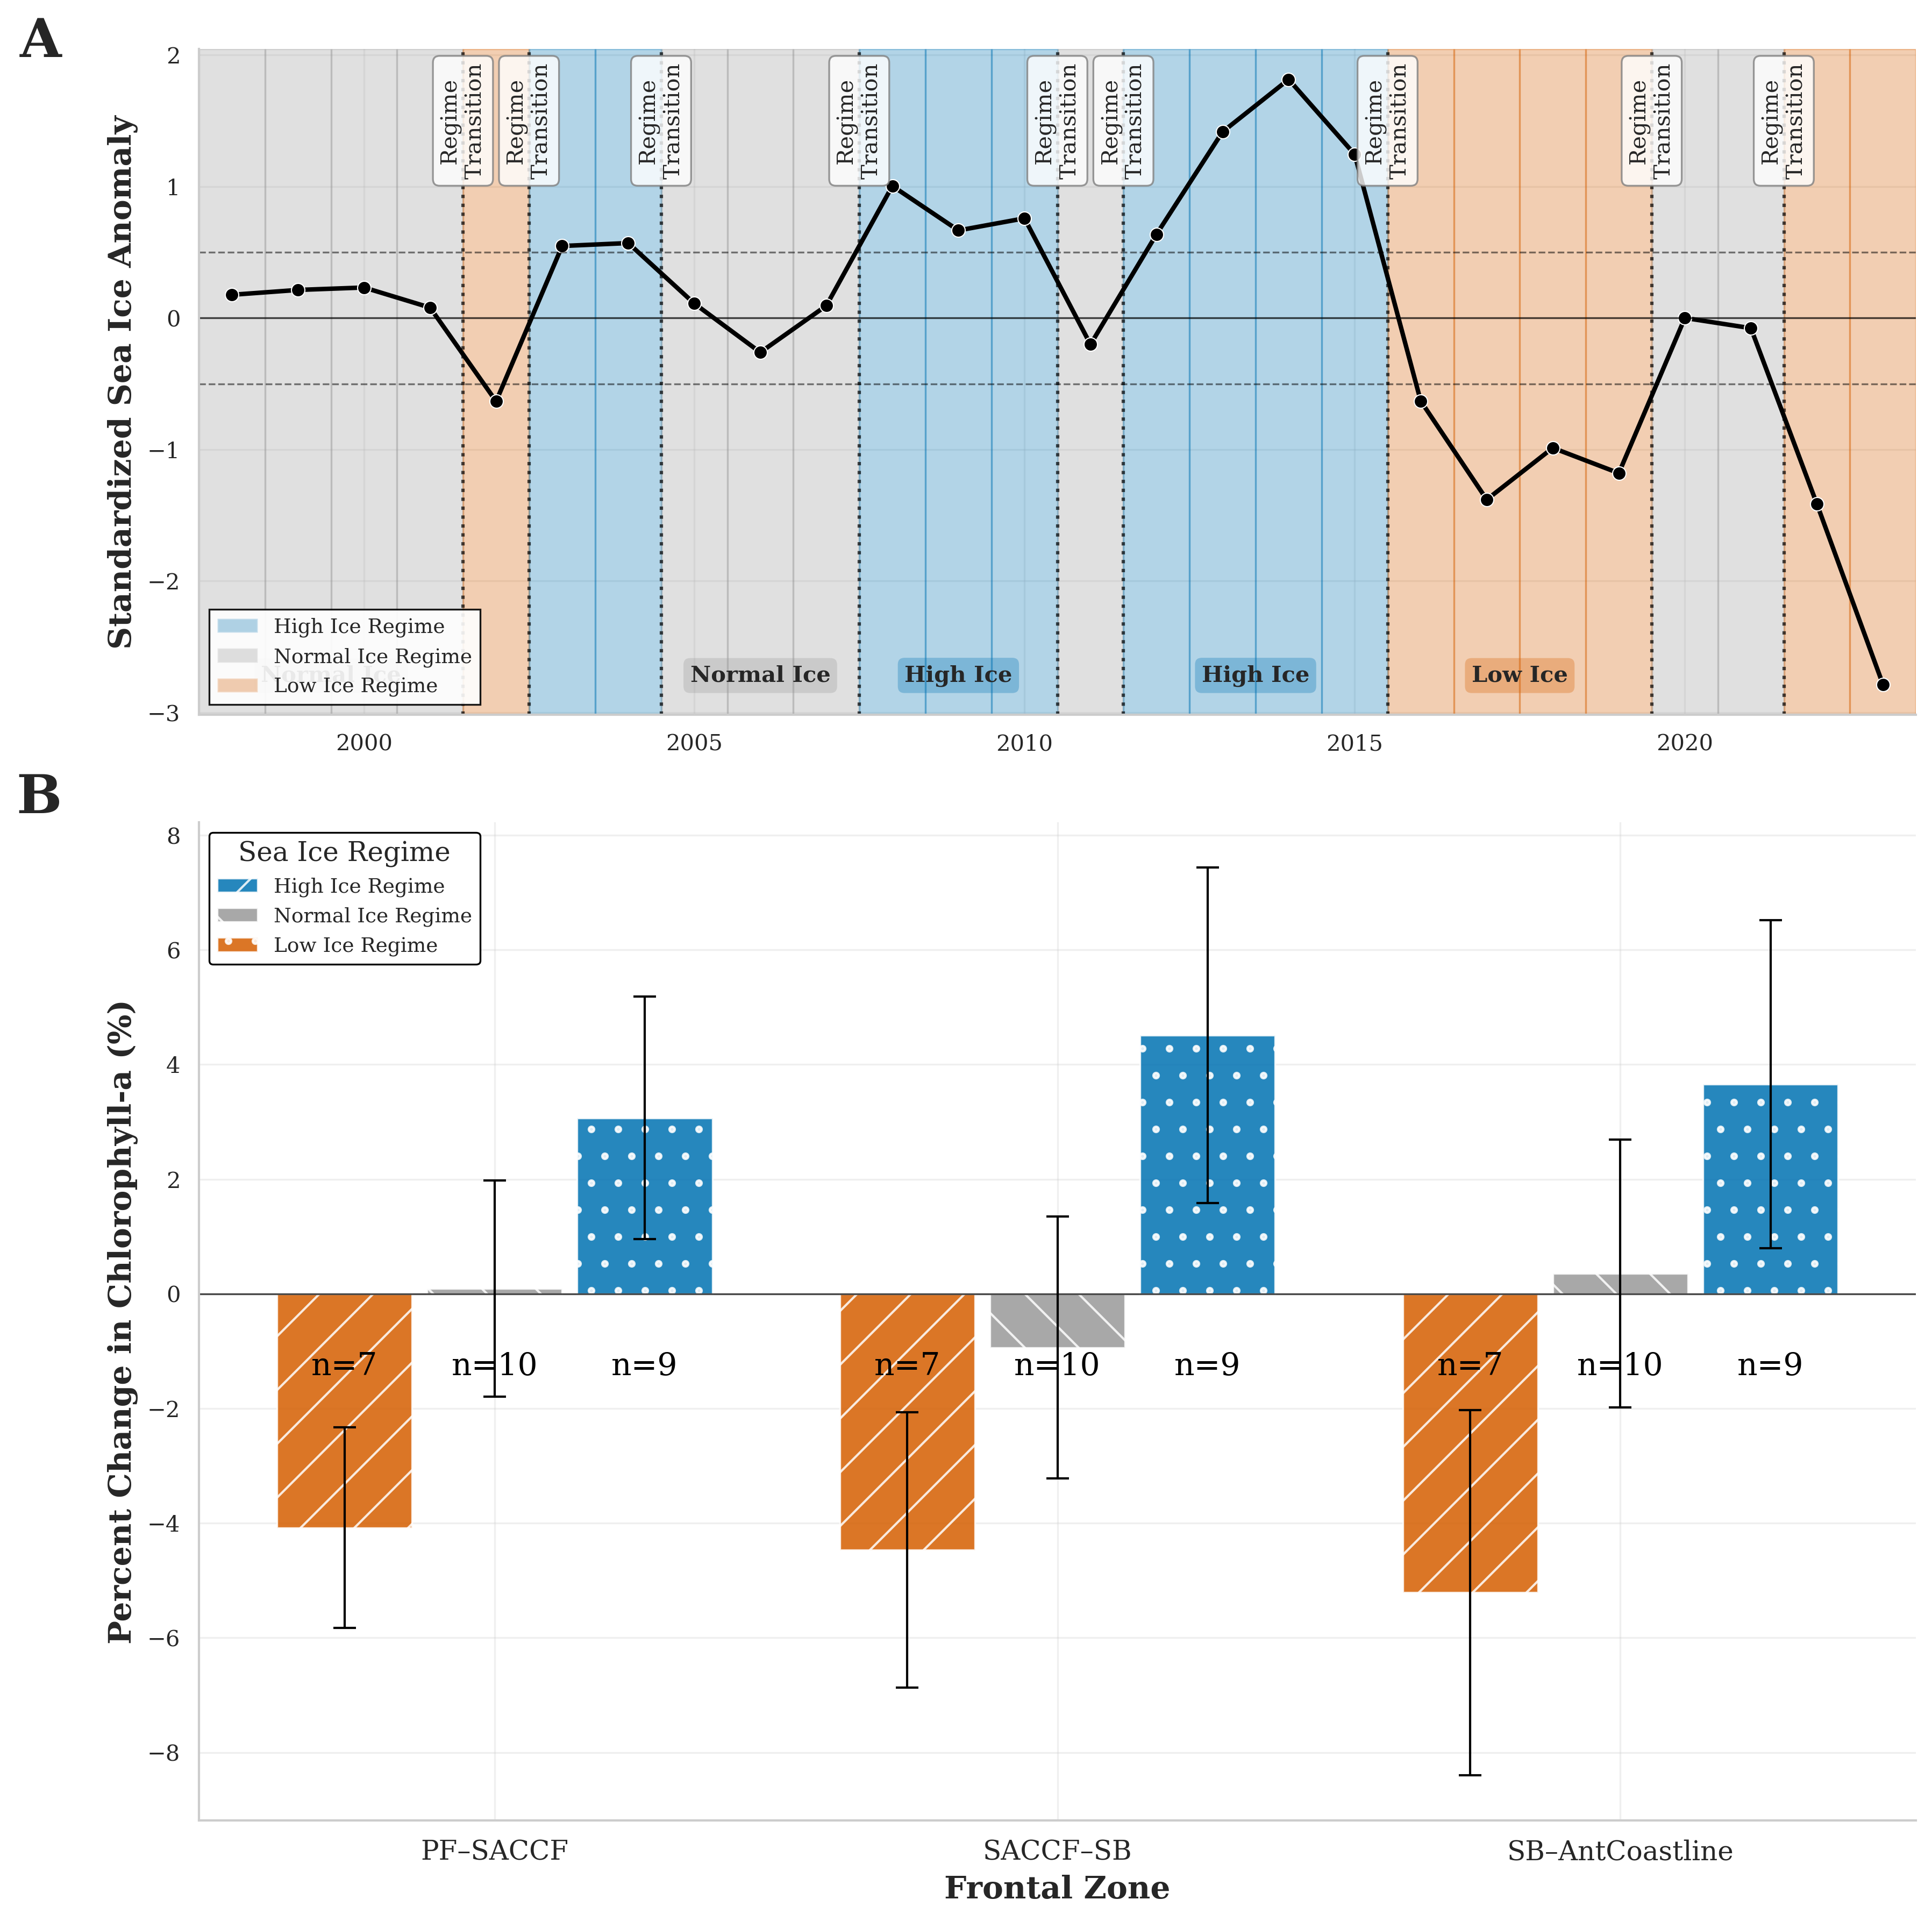

In [10]:
# Update matplotlib parameters without relying on seaborn
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# Force matplotlib to use serif fonts
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino', 'Computer Modern Roman'],
    'mathtext.fontset': 'dejavuserif',  # Valid value for mathtext.fontset
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'axes.linewidth': 1.0,
    'savefig.dpi': 600,
    'figure.figsize': (12, 12),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})

# Create a combined figure with sea ice regimes in upper panel and bar chart summary in lower panel
def create_combined_regime_bar_figure(regime_analysis, chl_by_regime, regions):
    """
    Create a journal-quality figure combining sea ice regimes in upper panel
    and bar chart summary of chlorophyll response by regime in lower panel
    
    Parameters:
    regime_analysis (dict): Sea ice regime analysis results
    chl_by_regime (dict): Chlorophyll response by regime
    regions (list): List of region names
    
    Returns:
    matplotlib.figure.Figure: The created figure
    """
    if regime_analysis is None or 'regime' not in regime_analysis:
        print("❌ Regime analysis data not available")
        return None
    
    if chl_by_regime is None:
        print("❌ Chlorophyll by regime data not available")
        return None
    
    # Create figure with pure matplotlib
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), dpi=300, 
                                  gridspec_kw={'height_ratios': [1, 1.5]})
    
    # Define colorblind-friendly palette manually
    regime_colors = {
        'Low Ice': '#D55E00',    # Red-like
        'Normal Ice': '#999999', # Gray
        'High Ice': '#0072B2'    # Blue
    }
    
    #----- UPPER PANEL: Sea Ice Regimes -----#
    # Plot sea ice anomalies and regimes on top panel
    years = regime_analysis['std_anomaly'].index.year
    years_range = np.arange(min(years), max(years) + 1)
    
    # Create colormap for regime background
    for year in years:
        regime = regime_analysis['regime'][f"{year}-12-31"]
        ax1.axvspan(year-0.5, year+0.5, alpha=0.3, color=regime_colors[regime])
    
    # Plot sea ice anomalies with enhanced styling and markers as requested
    ax1.plot(years, regime_analysis['std_anomaly'], color='black', linewidth=2, 
             marker='o', markersize=6, markeredgecolor='white', markeredgewidth=0.5,
             label="Sea Ice Extent Anomaly (Standardized)")
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
    
    # # Add text explaining standardization method
    # ax1.text(0.02, 0.98, 
    #          "Standardization: z = (x - μ)/σ\nwhere μ = mean, σ = standard deviation", 
    #          transform=ax1.transAxes, va='top', ha='left', fontsize=9,
    #          bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    # Add regime threshold lines with subtle styling
    ax1.axhline(y=0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax1.axhline(y=-0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Identify regime transitions
    regime_changes = []
    prev_regime = None
    for year in sorted(years):
        regime = regime_analysis['regime'][f"{year}-12-31"]
        if prev_regime is not None and regime != prev_regime:
            regime_changes.append(year)
        prev_regime = regime
    
    # Add vertical lines and labels for regime transitions
    for year in regime_changes:
        ax1.axvline(x=year-0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
        ax1.text(year-0.5, ax1.get_ylim()[1]*0.95, f"Regime\nTransition", 
                ha='center', va='top', fontsize=10, rotation=90,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
    
    # Format top panel for publication
    ax1.set_xlim(min(years)-0.5, max(years)+0.5)
    ax1.set_ylabel('Standardized Sea Ice Anomaly', fontsize=14, fontweight='bold')
    # ax1.set_title('Antarctic Sea Ice Regimes (1998-2023)', fontsize=16, fontweight='bold')
    
    # Add regime labels without the μ values (just regime names)
    for regime in ['Low Ice', 'Normal Ice', 'High Ice']:
        # Find years with this regime
        regime_years = [year for year in years if regime_analysis['regime'][f"{year}-12-31"] == regime]
        if regime_years:
            # Get continuous periods of the same regime
            periods = []
            start = regime_years[0]
            for i in range(1, len(regime_years)):
                if regime_years[i] != regime_years[i-1] + 1:
                    # End of consecutive sequence
                    periods.append((start, regime_years[i-1]))
                    start = regime_years[i]
            # Add the last sequence
            periods.append((start, regime_years[-1]))
            
            # For each distinct period with this regime
            for start_year, end_year in periods:
                mid_year = start_year + (end_year - start_year) / 2
                # Only annotate periods of sufficient length
                if end_year - start_year >= 2:
                    # Add regime label without the μ value
                    ax1.text(
                        mid_year, -2.8,  # Position at bottom of plot
                        f"{regime}",
                        ha='center', va='bottom', fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle='round', facecolor=regime_colors[regime], 
                                  alpha=0.3, edgecolor='none')
                    )
    
    # Add panel label (A)
    ax1.text(-0.08, 1.05, 'A', transform=ax1.transAxes, 
             fontsize=24, fontweight='bold', va='top', ha='right')
    
    # Add regime labels to the legend
    legend_elements = [
        Patch(facecolor=regime_colors['High Ice'], alpha=0.3, label='High Ice Regime'),
        Patch(facecolor=regime_colors['Normal Ice'], alpha=0.3, label='Normal Ice Regime'),
        Patch(facecolor=regime_colors['Low Ice'], alpha=0.3, label='Low Ice Regime')
    ]
    ax1.legend(handles=legend_elements, loc='lower left', frameon=True, fancybox=False, 
               framealpha=0.9, edgecolor='black')
    
    #----- LOWER PANEL: Chlorophyll-a Response Bar Chart with Standard Error -----#
    # Set up bar positions
    regimes = ['Low Ice', 'Normal Ice', 'High Ice']
    region_labels_dict = {'PF_SACCF': 'PF–SACCF', 'SACCF_SB': 'SACCF–SB', 'SB_AntCoastline': 'SB–AntCoastline'}
    
    # Create a DataFrame for easier plotting
    plot_data = []
    
    for region in regions:
        if region in chl_by_regime:
            for regime in regimes:
                if regime in chl_by_regime[region]:
                    # Calculate standard error instead of using standard deviation
                    mean = chl_by_regime[region][regime]['mean']
                    std = chl_by_regime[region][regime]['std']
                    count = chl_by_regime[region][regime]['count']
                    
                    # Standard Error = Standard Deviation / sqrt(sample size)
                    se = std / np.sqrt(count) if count > 0 else 0
                    
                    plot_data.append({
                        'Region': region_labels_dict[region],
                        'Regime': regime,
                        'Percent Change': mean,
                        'Error': se,  # Now using standard error
                        'StdDev': std, # Keep standard deviation for reference
                        'Count': count
                    })
    
    plot_df = pd.DataFrame(plot_data)
    
    if not plot_df.empty:
        # Set up positions for grouped bars
        unique_regions = plot_df['Region'].unique()
        unique_regimes = plot_df['Regime'].unique()
        n_regions = len(unique_regions)
        n_regimes = len(unique_regimes)
        
        # Width of a group of bars
        group_width = 0.8
        # Width of each bar
        bar_width = group_width / n_regimes
        
        # Create a barplot manually for more control
        x_positions = {}
        
        for i, region in enumerate(unique_regions):
            x_center = i
            for j, regime in enumerate(unique_regimes):
                # Position for this specific bar
                x_pos = x_center + (j - (n_regimes-1)/2) * bar_width
                x_positions[(region, regime)] = x_pos
                
                # Get data for this bar
                data = plot_df[(plot_df['Region'] == region) & (plot_df['Regime'] == regime)]
                if not data.empty:
                    value = data.iloc[0]['Percent Change']
                    error = data.iloc[0]['Error']  # Standard error
                    std_dev = data.iloc[0]['StdDev']  # Keep std dev for reference
                    count = data.iloc[0]['Count']
                    
                    # Create bar
                    bar = ax2.bar(x_pos, value, width=bar_width * 0.9, 
                                  color=regime_colors[regime], alpha=0.85)
                    
                    # Add error bars (now using standard error)
                    ax2.errorbar(x_pos, value, yerr=error, fmt='none', color='black', 
                                 capsize=5, capthick=1, linewidth=1)
                    
                    # Add hatching to differentiate bars (colorblind-friendly)
                    hatches = ['/', '\\', '.']
                    bar[0].set_hatch(hatches[j % len(hatches)])
                    
                    # Add count labels below each bar
                    ax2.text(
                        x_pos,
                        -1,  # Just below x-axis
                        f"n={count}", 
                        ha='center', 
                        va='top', 
                        fontsize=14, 
                        color='black',
                        fontweight='normal'
                    )
                    
        
        # Set x-axis ticks to region names
        ax2.set_xticks(range(len(unique_regions)))
        ax2.set_xticklabels(unique_regions, fontsize=12)
    
    # Format bottom panel for publication
    ax2.set_xlabel('Frontal Zone', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Percent Change in Chlorophyll-a (%)', fontsize=14, fontweight='bold')
    # ax2.set_title('Chlorophyll-a Response by Sea Ice Regime (1998-2023)', fontsize=16, fontweight='bold')
    
    # Add panel label (B)
    ax2.text(-0.08, 1.05, 'B', transform=ax2.transAxes, 
             fontsize=24, fontweight='bold', va='top', ha='right')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
    
    # Create custom legend for regimes
    legend_elements = [
        Patch(facecolor=regime_colors['High Ice'], alpha=0.85, label='High Ice Regime', hatch='/'),
        Patch(facecolor=regime_colors['Normal Ice'], alpha=0.85, label='Normal Ice Regime', hatch='\\'),
        Patch(facecolor=regime_colors['Low Ice'], alpha=0.85, label='Low Ice Regime', hatch='.')
    ]
    
    # Enhance legend for publication
    ax2.legend(
        handles=legend_elements,
        title='Sea Ice Regime', 
        title_fontsize=12,
        frameon=True, 
        loc='best',
        edgecolor='black',
        framealpha=1.0
    )
    
    # Grid and spine styling
    ax1.grid(True, alpha=0.3)
    ax2.grid(True, alpha=0.3)
    
    # Remove top and right spines for cleaner look
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.savefig("/A04/so_data/ubuntu/Chapter_2/Figures_GRL/Figure_5.png", dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    
    # # Add a note about data source and analysis method
    # fig.text(0.01, 0.01, 
    #          "Source: Sea Ice Extent Anomaly (SIEA) and Chlorophyll-a data 1998-2023", 
    #          fontsize=8, style='italic')
    
    return fig

# Create combined regime and bar chart figure
combined_bar_figure = create_combined_regime_bar_figure(regime_analysis, chl_by_regime, regions)
plt.show()